## 1. Load data from Supabase

In [8]:
from sqlalchemy import create_engine
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

host = os.getenv("SUPABASE_HOST")
user = os.getenv("SUPABASE_USER")
password = os.getenv("SUPABASE_PASSWORD")

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:6543/postgres")

query = """
    SELECT
        a.activity_name, a.start_date, a.activity_type,
        a.distance, a.duration, a.elevation,
        a.max_speed, a.avg_speed, a.avg_heartrate,
        a.suffer_score, a.avg_watts, a.kilojoules,
        a.start_lat, a.start_lng, a.end_lat, a.end_lng
    FROM activities a
    JOIN athletes ath ON a.athlete_id = ath.id
    ORDER BY a.start_date DESC
"""

df = pd.read_sql(query, engine)
df["start_date"] = pd.to_datetime(df["start_date"])

splits_query = """
    SELECT
        s.id AS split_id,
        s.activity_id,
        s.split_number,
        s.distance_km,
        s.elapsed_time_s,
        s.moving_time_s,
        s.elevation_diff_m,
        s.avg_speed_kmh,
        s.avg_heartrate,
        s.pace_zone,
        a.activity_name,
        a.start_date,
        a.activity_type
    FROM splits s
    JOIN activities a ON s.activity_id = a.id
    ORDER BY a.start_date DESC, s.split_number ASC
"""

df_splits = pd.read_sql(splits_query, engine)
df_splits["start_date"] = pd.to_datetime(df_splits["start_date"])

In [9]:
## Check df variables

import json
print(df)

                         activity_name          start_date activity_type  \
0                         Morning Swim 2026-08-03 07:38:49          Swim   
1    Long Run: Target sub 5:00/km pace 2026-08-02 11:07:21           Run   
2                             Base Run 2026-08-01 14:16:30           Run   
3                       Afternoon Ride 2026-07-31 16:47:17          Ride   
4                             Base Run 2026-07-31 11:36:32           Run   
..                                 ...                 ...           ...   
351                      Afternoon Run 2021-10-05 17:07:34           Run   
352                      Afternoon Run 2021-10-03 16:11:24           Run   
353                          Lunch Run 2021-09-28 12:42:38           Run   
354                        Morning Run 2021-09-25 09:04:20           Run   
355                        Evening Run 2021-09-22 18:02:29           Run   

     distance    duration  elevation  max_speed  avg_speed  avg_heartrate  \
0      1.4

## 2. Visualize activity results
Plot various metrics from the Strava activities, such as distance, duration, elevation gain, and average speed over time.

In [ ]:
%matplotlib widget
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplcursors

FIGURES_DIR = r"C:\Users\persif\PycharmProjects\SportAnalytics\figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

runs = (df[(df["activity_type"] == "Run")]
        .dropna(subset=["distance"])
        .sort_values("start_date"))

fig, ax = plt.subplots(figsize=(12, 4))
line, = ax.plot(runs["start_date"], runs["distance"], marker="o", linewidth=1, markersize=4, color="steelblue")
ax.fill_between(runs["start_date"], runs["distance"], alpha=0.15, color="steelblue")

ax.set_title("Distance Run Over Time", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Distance (km)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "distance_over_time.png"), dpi=150)

cursor = mplcursors.cursor(line, hover=False)
prev_sel = [None]

@cursor.connect("add")
def on_add(sel, p=prev_sel):
    if p[0] is not None:
        p[0].annotation.set_visible(False)
        fig.canvas.draw_idle()
    p[0] = sel
    idx = sel.index
    row = runs.iloc[idx]
    sel.annotation.set_text(
        f"{row['start_date'].strftime('%d %b %Y')}\n"
        f"Distance: {row['distance']:.1f} km\n"
        f"Suffer Score: {row.get('suffer_score', 'N/A')}"
    )

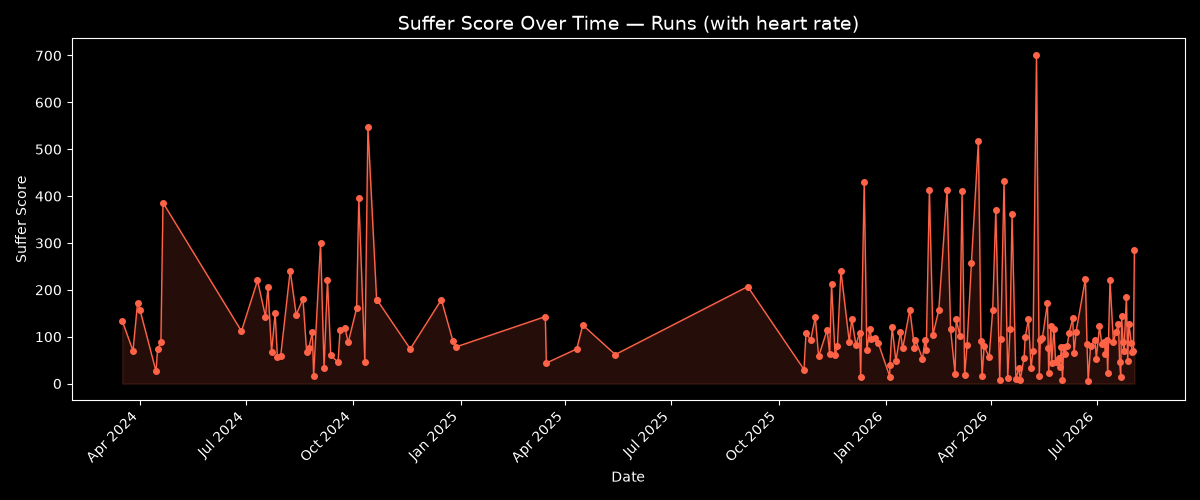

In [10]:
## VISUALIZE SUFFER SCORE ALL TIME

import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

FIGURES_DIR = r"C:\Users\persif\PycharmProjects\SportAnalytics\figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

runs = (df[(df["activity_type"] == "Run")]
        .dropna(subset=["suffer_score", "avg_heartrate"])
        .sort_values("start_date"))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(runs["start_date"], runs["suffer_score"], marker="o", linewidth=1, markersize=4, color="tomato")
ax.fill_between(runs["start_date"], runs["suffer_score"], alpha=0.15, color="tomato")

ax.set_title("Suffer Score Over Time — Runs (with heart rate)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Suffer Score")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "suffer_score_over_time.png"), dpi=150)
plt.show()

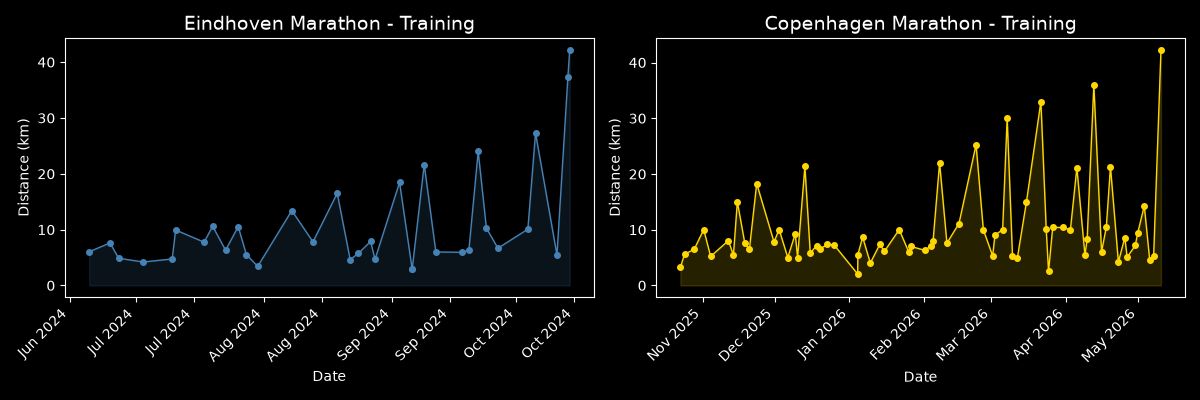

In [12]:
%matplotlib widget
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplcursors
import pandas as pd

FIGURES_DIR = r"C:\Users\persif\PycharmProjects\SportAnalytics\figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

runs = (df[df["activity_type"] == "Run"]
        .dropna(subset=["distance"])
        .sort_values("start_date"))

marathon1 = runs[(runs["start_date"] >= "2024-06-01") & (runs["start_date"] < "2024-10-14")]
marathon2 = runs[(runs["start_date"] >= "2025-10-20") & (runs["start_date"] < "2026-05-11")]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

cursors = []

for ax, data, title, color in [
    (ax1, marathon1, "Eindhoven Marathon - Training", "steelblue"),
    (ax2, marathon2, "Copenhagen Marathon - Training", "gold"),
]:
    line, = ax.plot(data["start_date"], data["distance"], marker="o", linewidth=1, markersize=4, color=color)
    ax.fill_between(data["start_date"], data["distance"], alpha=0.15, color=color)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel("Distance (km)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    cursor = mplcursors.cursor(line, hover=False)
    cursors.append(cursor)
    prev_sel = [None]

    @cursor.connect("add")
    def on_add(sel, d=data, p=prev_sel):
        if p[0] is not None:
            p[0].annotation.set_visible(False)
            fig.canvas.draw_idle()
        p[0] = sel
        row = d.iloc[sel.index]
        sel.annotation.set_text(
            f"{row['start_date'].strftime('%d %b %Y')}\n"
            f"Distance: {row['distance']:.1f} km\n"
            f"Suffer Score: {row.get('suffer_score', 'N/A')}"
        )

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "marathon_training_comparison.png"), dpi=150)
plt.show()

In [ ]:
%matplotlib widget
import os
import matplotlib.pyplot as plt
import pandas as pd

FIGURES_DIR = r"C:\Users\persif\PycharmProjects\SportAnalytics\figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

runs = (df[df["activity_type"] == "Run"]
        .dropna(subset=["distance"])
        .sort_values("start_date"))

# Training windows
start1 = pd.Timestamp("2024-06-01")
start2 = pd.Timestamp("2025-10-20")
start3 = pd.Timestamp("2026-06-15")

m1 = runs[(runs["start_date"] >= start1) & (runs["start_date"] < "2024-10-14")].copy()
m2 = runs[(runs["start_date"] >= start2) & (runs["start_date"] < "2026-05-11")].copy()
m3 = runs[runs["start_date"] >= start3].copy()

def weekly_long_run(data, start):
    d = data.copy()
    d["week"] = (d["start_date"] - start).dt.days // 7
    wk = d.groupby("week")["distance"].max().reset_index()
    wk["month"] = (wk["week"] * 7 + 3.5) / 30.44 + 1
    return wk

def monthly_volume(data, start):
    d = data.copy()
    d["month_bin"] = (d["start_date"] - start).dt.days // 30 + 1
    return d.groupby("month_bin")["distance"].sum().reset_index().rename(
        columns={"month_bin": "month", "distance": "total_dist"})

wlr1 = weekly_long_run(m1, start1)
wlr2 = weekly_long_run(m2, start2)
wlr3 = weekly_long_run(m3, start3)
vol1  = monthly_volume(m1, start1)
vol2  = monthly_volume(m2, start2)
vol3  = monthly_volume(m3, start3)

CREAM = "#C8B98A"

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(12, 8),
    gridspec_kw={"height_ratios": [2, 1]}
)

# --- Top: individual runs (faded) + weekly long run line ---
ax_top.scatter(
    (m1["start_date"] - start1).dt.days / 30.44 + 1, m1["distance"],
    alpha=0.2, color="steelblue", s=18, zorder=2
)
ax_top.scatter(
    (m2["start_date"] - start2).dt.days / 30.44 + 1, m2["distance"],
    alpha=0.2, color="goldenrod", s=18, zorder=2
)
ax_top.scatter(
    (m3["start_date"] - start3).dt.days / 30.44 + 1, m3["distance"],
    alpha=0.4, color=CREAM, s=18, zorder=2
)

ax_top.plot(wlr1["month"], wlr1["distance"], color="steelblue", linewidth=2, marker="o", markersize=5, label="Eindhoven Marathon 2024")
ax_top.plot(wlr2["month"], wlr2["distance"], color="goldenrod",  linewidth=2, marker="o", markersize=5, label="Copenhagen Marathon 2026")
ax_top.plot(wlr3["month"], wlr3["distance"], color=CREAM,        linewidth=2, marker="o", markersize=5, label="Amsterdam Marathon 2026 (in progress)")
ax_top.fill_between(wlr1["month"], 0, wlr1["distance"], alpha=0.08, color="steelblue")
ax_top.fill_between(wlr2["month"], 0, wlr2["distance"], alpha=0.08, color="goldenrod")

ax_top.set_ylabel("Weekly long run (km)", fontsize=12)
ax_top.set_title("Marathon Training Trajectory Comparison", fontsize=14)
ax_top.legend(loc="upper left", fontsize=10)
ax_top.set_xticks(range(1, 8))
ax_top.set_xlim(0.5, 7.5)
ax_top.set_ylim(bottom=0)
ax_top.grid(axis="y", alpha=0.3, linestyle=":")

# --- Bottom: monthly total volume bars ---
bar_w = 0.25
ax_bot.bar(vol1["month"] - bar_w, vol1["total_dist"], width=bar_w, color="steelblue", alpha=0.75, label="Eindhoven")
ax_bot.bar(vol2["month"],          vol2["total_dist"], width=bar_w, color="goldenrod",  alpha=0.75, label="Copenhagen")
ax_bot.bar(vol3["month"] + bar_w, vol3["total_dist"], width=bar_w, color=CREAM,        alpha=0.9,  label="Amsterdam")
ax_bot.set_ylabel("Monthly volume (km)", fontsize=12)
ax_bot.set_xlabel("Month of training", fontsize=12)
ax_bot.set_xticks(range(1, 8))
ax_bot.set_xlim(0.5, 7.5)
ax_bot.set_ylim(bottom=0)
ax_bot.legend(fontsize=10)
ax_bot.grid(axis="y", alpha=0.3, linestyle=":")

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "marathon_training_trend.png"), dpi=150)
plt.show()

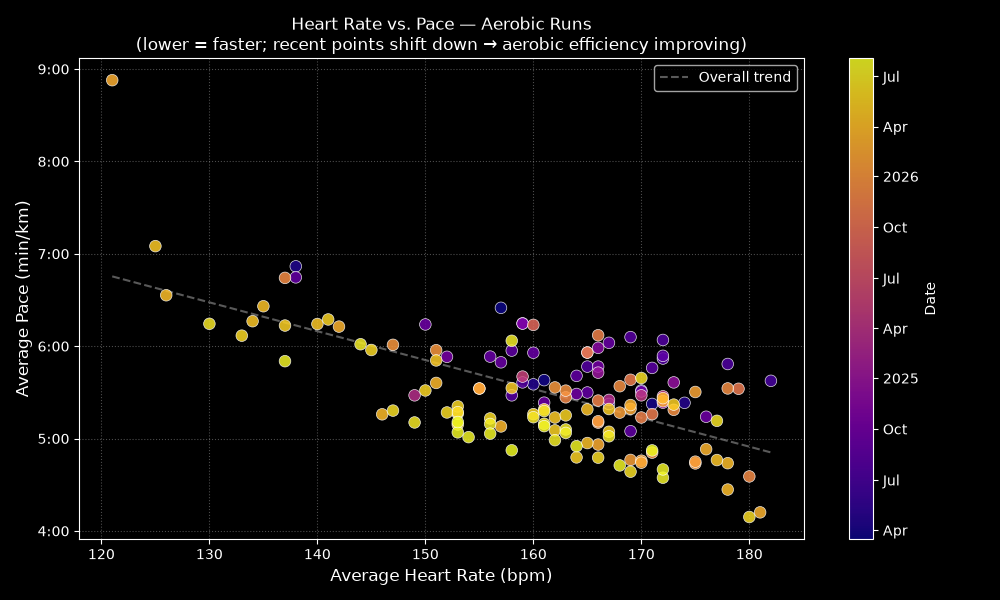

Runs plotted: 150


In [14]:
%matplotlib widget
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

FIGURES_DIR = r"C:\Users\persif\PycharmProjects\SportAnalytics\figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Include generic easy runs (Morning/Afternoon/Base/Evening/Lunch Run etc.)
# Exclude structured workouts by name
EXCLUDE = r"interval|sprint|tempo|fartlek|race|hill repeat|track workout"

easy_runs = (
    df[
        (df["activity_type"] == "Run") &
        (~df["activity_name"].str.contains(EXCLUDE, case=False, na=False)) &
        df["avg_heartrate"].notna() &
        df["avg_speed"].notna()
    ]
    .sort_values("start_date")
    .copy()
)

easy_runs["pace_min_per_km"] = 60.0 / easy_runs["avg_speed"]

dates_num = mdates.date2num(easy_runs["start_date"].dt.to_pydatetime())

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    easy_runs["avg_heartrate"],
    easy_runs["pace_min_per_km"],
    c=dates_num,
    cmap="plasma",
    s=70,
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
    zorder=3,
)

if len(easy_runs) >= 2:
    z = np.polyfit(easy_runs["avg_heartrate"], easy_runs["pace_min_per_km"], 1)
    p = np.poly1d(z)
    hr_range = np.linspace(easy_runs["avg_heartrate"].min(), easy_runs["avg_heartrate"].max(), 200)
    ax.plot(hr_range, p(hr_range), "--", color="gray", linewidth=1.5, alpha=0.7, label="Overall trend")
    ax.legend(fontsize=10)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Date", fontsize=10)
loc = mdates.AutoDateLocator()
cbar.ax.yaxis.set_major_locator(loc)
cbar.ax.yaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

def pace_formatter(x, _):
    mins = int(x)
    secs = int(round((x - mins) * 60))
    return f"{mins}:{secs:02d}"

ax.yaxis.set_major_formatter(plt.FuncFormatter(pace_formatter))
ax.set_xlabel("Average Heart Rate (bpm)", fontsize=12)
ax.set_ylabel("Average Pace (min/km)", fontsize=12)
ax.set_title("Heart Rate vs. Pace — Aerobic Runs\n(lower = faster; recent points shift down → aerobic efficiency improving)", fontsize=12)
ax.grid(alpha=0.3, linestyle=":")

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "hr_vs_pace_aerobic_runs.png"), dpi=150)
plt.show()

print(f"Runs plotted: {len(easy_runs)}")